<h4>Funkcja do wczytywania</h4>

In [20]:
def load_sudoku(filename):
    # Initialize an empty list to represent the 9x9 board
    board = []
    
    # Open the text file in read mode
    with open(filename, 'r') as file:
        for line in file:
            # Remove newline characters and any surrounding whitespace
            line = line.strip()
            
            # Skip empty lines if there are any

                
            row = []
            # Iterate through each character in the line
            for char in line:
                if char == 'x':
                    # Replace 'x' with 0 to indicate an empty cell
                    row.append(0)
                else:
                    # Convert string digit to integer
                    row.append(int(char))
                    
            # Add the processed row to the board
            board.append(row)
            
    return board



<h4>Funkcja do wyświetlania</h4>

In [21]:
import matplotlib.pyplot as plt
from io import BytesIO
from PIL import Image

def draw_sudoku(initial_board, solved_board):
    # Create a figure with two subplots side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    # Helper function to draw a single board on a given axis
    def draw_board(ax, board, base_board=None, title=""):
        # Set axis limits and invert Y axis so (0,0) is at the top-left
        ax.set_xlim(0, 9)
        ax.set_ylim(0, 9)
        ax.invert_yaxis()
        ax.set_aspect('equal')
        ax.axis('off') # Hide default axes
        ax.set_title(title, fontsize=16)
        
        # Draw the grid lines
        for i in range(10):
            # Thicker lines for 3x3 block borders, thinner for individual cells
            linewidth = 2.5 if i % 3 == 0 else 0.5
            ax.plot([0, 9], [i, i], color='black', linewidth=linewidth)
            ax.plot([i, i], [0, 9], color='black', linewidth=linewidth)
            
        # Fill the grid with numbers
        for row in range(9):
            for col in range(9):
                val = board[row][col]
                if val != 0:
                    # Default text color is black
                    text_color = 'black'
                    # Highlight numbers added by the solver in blue
                    if base_board and base_board[row][col] == 0:
                        text_color = 'blue'
                        
                    # Place the text in the center of the cell
                    ax.text(col + 0.5, row + 0.5, str(val), 
                            ha='center', va='center', fontsize=16, color=text_color)

    # Draw the initial board on the left
    draw_board(axes[0], initial_board, title="Initial Board")
    
    # Draw the solved board on the right, using initial board for color reference
    draw_board(axes[1], solved_board, base_board=initial_board, title="Solved Board")
    
    # Adjust layout so elements do not overlap
    plt.tight_layout()
    
    # Save the plot to an in-memory byte buffer instead of a file
    buf = BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight', dpi=150)
    buf.seek(0)
    
    # Open the image from the buffer using PIL
    img = Image.open(buf)
    
    plt.show()
    # Close the matplotlib figure to free up memory
    plt.close(fig)
    
    # Return the PIL Image object
    
    
    # You can show it directly:
    #result_image.show()
    
    # Or save it to a file:
    # result_image.save("sudoku_result.png")

<h4>Wykres Energii</h4>

In [22]:
import matplotlib.pyplot as plt

def plot_energy_and_temp(energies, temps=None):
    """
    Plots the energy of the system over iterations.
    Optionally plots the temperature on a secondary y-axis.
    """
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Plot Energy on the primary Y-axis (left)
    color_energy = 'tab:blue'
    ax1.set_xlabel('Iteration (Step)')
    ax1.set_ylabel('Total Energy', color=color_energy, fontweight='bold')
    ax1.plot(energies, color=color_energy, alpha=0.9, linewidth=1)
    ax1.tick_params(axis='y', labelcolor=color_energy)
    ax1.grid(True, linestyle='--', alpha=0.5)

    # Plot Temperature on the secondary Y-axis (right) if provided
    if temps is not None:
        ax2 = ax1.twinx()  
        color_temp = 'tab:red'
        ax2.set_ylabel('Temperature', color=color_temp, fontweight='bold')
        ax2.plot(temps, color=color_temp, alpha=0.8, linewidth=2, linestyle=':')
        ax2.tick_params(axis='y', labelcolor=color_temp)
        plt.title('Energy Minimization and Cooling Schedule', fontsize=14)
    else:
        plt.title('Energy Minimization Over Time', fontsize=14)

    # Ensure layout fits well and labels aren't cut off
    fig.tight_layout()  
    plt.show()

# Example usage based on your previous code:
# plot_energy_and_temp(energies, temps)

<h4>Generacja losowych kwadratów</h4>

In [23]:
import random, copy

def fill_blocks_and_get_movable(init_board):
    new_board = copy.deepcopy(init_board)
    # Create a list of 9 empty lists to store movable coordinates for each 3x3 block
    movable_cells_by_block = [[] for _ in range(9)]
    
    # Iterate over all 9 blocks (indexed 0 to 8)
    for block_idx in range(9):
        # Calculate the starting row and column for the current block
        start_row = (block_idx // 3) * 3
        start_col = (block_idx % 3) * 3
        
        fixed_numbers = set()
        empty_cells = []
        
        # Scan the 3x3 block to find fixed numbers and empty cells
        for r in range(start_row, start_row + 3):
            for c in range(start_col, start_col + 3):
                val = new_board[r][c]
                if val != 0:
                    fixed_numbers.add(val)
                else:
                    # Save the coordinates of the empty cell
                    empty_cells.append((r, c))
                    
        # Determine which numbers (1-9) are missing in this block
        all_numbers = set(range(1, 10))
        missing_numbers = list(all_numbers - fixed_numbers)
        
        # Shuffle the missing numbers to place them randomly
        random.shuffle(missing_numbers)
        
        # Fill the empty cells on the board with the shuffled numbers
        # and store their coordinates in our map
        for (r, c), num in zip(empty_cells, missing_numbers):
            new_board[r][c] = num
            movable_cells_by_block[block_idx].append((r, c))
            
    # Return both the filled board and the map of movable cells
    return new_board, movable_cells_by_block




<h4>Energia oraz tempertura</h4>

In [24]:
import math

# --- TOTAL ENERGY FUNCTION ---
def calculate_total_energy(board):
    # Calculates the total cost for the entire 9x9 board.
    # Used only once at the very beginning of the algorithm.
    cost = 0
    
    for i in range(9):
        # Calculate duplicates in the i-th row
        row_unique = len(set(board[i]))
        cost += (9 - row_unique)
        
        # Calculate duplicates in the i-th column
        col_values = [board[r][i] for r in range(9)]
        col_unique = len(set(col_values))
        cost += (9 - col_unique)
        
    return cost

# --- PARTIAL ENERGY FUNCTION ---
def calculate_partial_energy(board, block_idx):
    # Calculates the cost ONLY for the 3 rows and 3 columns 
    # that intersect with the specified 3x3 block.
    # Used inside the simulated annealing loop to find delta_E.
    cost = 0
    
    # Determine the starting row and column for the given block index (0-8)
    start_row = (block_idx // 3) * 3
    start_col = (block_idx % 3) * 3
    
    # Check the 3 affected rows
    for r in range(start_row, start_row + 3):
        row_unique = len(set(board[r]))
        cost += (9 - row_unique)
        
    # Check the 3 affected columns
    for c in range(start_col, start_col + 3):
        col_values = [board[row][c] for row in range(9)]
        col_unique = len(set(col_values))
        cost += (9 - col_unique)
        
    return cost



def temp_exp(iteration, par, inital_temp):
    return inital_temp * (par ** iteration)

<h4>Główna funkcja</h4>

In [25]:
def solve_sudoku_sa(board, initial_temp, cooling_rate, min_temp, max_iterations):
    working_board = copy.deepcopy(board)
    

    working_board, movable_map = fill_blocks_and_get_movable(working_board)
    
    valid_blocks = [idx for idx in range(9) if len(movable_map[idx]) >= 2]
    
    if not valid_blocks:
        initial_cost = calculate_total_energy(working_board)
        return working_board, 0, [initial_cost]

    current_energy = calculate_total_energy(working_board)
    
    T = initial_temp
    iterations = 0
    energies = [current_energy]
    
    # 5. Main Simulated Annealing Loop
    # We loop until temperature is too low, we found the solution (energy == 0), 
    # or we hit the safety limit of iterations.
    while T > min_temp and current_energy > 0 and iterations < max_iterations:
        iterations += 1
        
        # Pick a random valid 3x3 block
        block_idx = random.choice(valid_blocks)
        movable_cells = movable_map[block_idx]
        
        # Pick two distinct cells to swap
        cell1, cell2 = random.sample(movable_cells, 2)
        r1, c1 = cell1
        r2, c2 = cell2
        
        # Calculate partial energy BEFORE the swap
        old_partial_energy = calculate_partial_energy(working_board, block_idx)
        
        # Execute the swap
        working_board[r1][c1], working_board[r2][c2] = working_board[r2][c2], working_board[r1][c1]
        
        # Calculate partial energy AFTER the swap
        new_partial_energy = calculate_partial_energy(working_board, block_idx)
        
        # Calculate Delta E
        delta_E = new_partial_energy - old_partial_energy
        
        # Decide whether to accept the new state
        # If delta_E < 0, it's a better state.
        if delta_E < 0:
            current_energy += delta_E
        else:
            # If it's worse, calculate probability
            probability = math.exp(-delta_E / T)
            if random.random() < probability:
                # Accept worse state
                current_energy += delta_E
            else:
                # Reject: revert the swap to return to the previous state
                working_board[r1][c1], working_board[r2][c2] = working_board[r2][c2], working_board[r1][c1]
        
        # Record the energy at this iteration
        energies.append(current_energy)
        
        # Cool down the temperature
        T = temp_exp(iterations, cooling_rate,initial_temp)
        
    return working_board, iterations, energies

<h4>Sudoku Checker</h4>

In [31]:
def is_valid_sudoku(board):
    # We will use lists of sets to track the numbers we have seen
    seen_rows = [set() for _ in range(9)]
    seen_cols = [set() for _ in range(9)]
    seen_boxes = [set() for _ in range(9)]

    for row in range(9):
        for col in range(9):
            num = board[row][col]

            # Ignore empty spaces, which can be represented by 0 or '.'
            if num == 0 or num == '.':
                continue

            # The box index formula maps the 9x9 grid into nine 3x3 boxes (indexed 0-8)
            box_index = (row // 3) * 3 + (col // 3)

            # If the number is already in the current row, column, or 3x3 box, the board is invalid
            if num in seen_rows[row] or num in seen_cols[col] or num in seen_boxes[box_index]:
                return False

            # Record the number as seen in its respective row, column, and box
            seen_rows[row].add(num)
            seen_cols[col].add(num)
            seen_boxes[box_index].add(num)

    # If the loop finishes without finding any duplicates, the board is valid
    return True

--- Solving Easy Sudoku ---
The solution of sudoku was: True
SUCCESS! Found perfect solution in 18578 iterations.


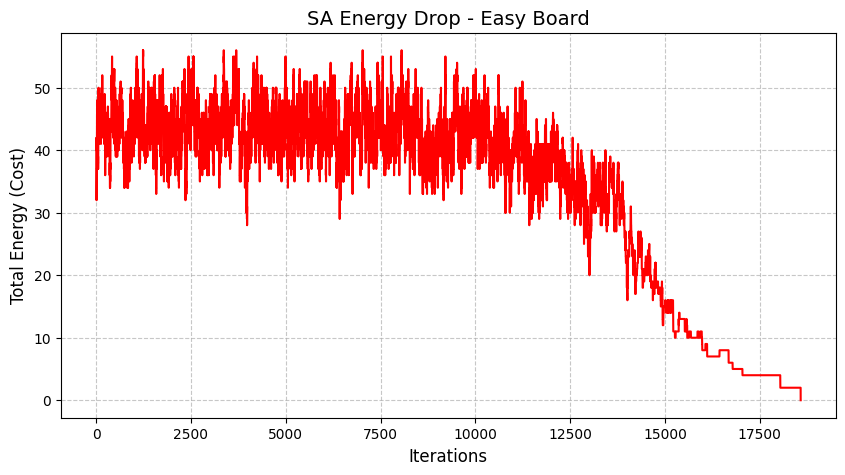

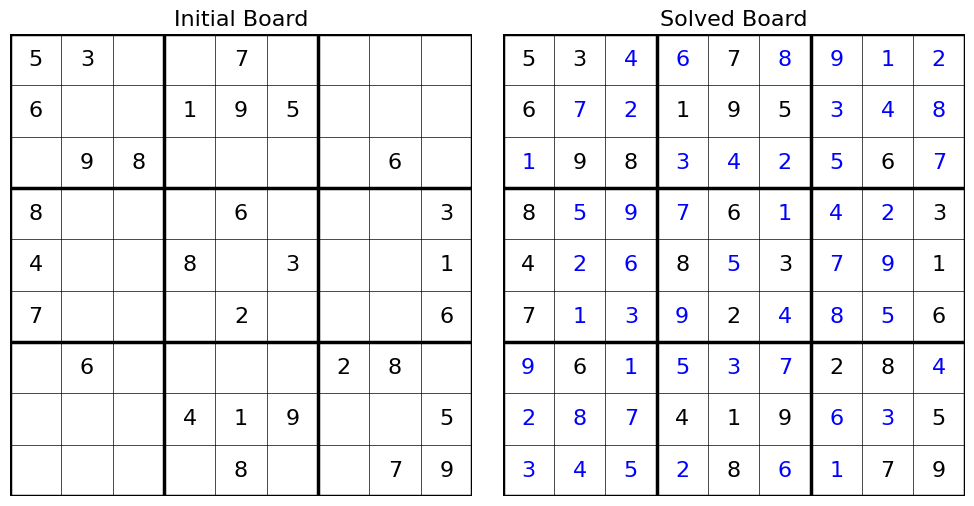



--- Solving Medium Sudoku ---
The solution of sudoku was: True
SUCCESS! Found perfect solution in 15530 iterations.


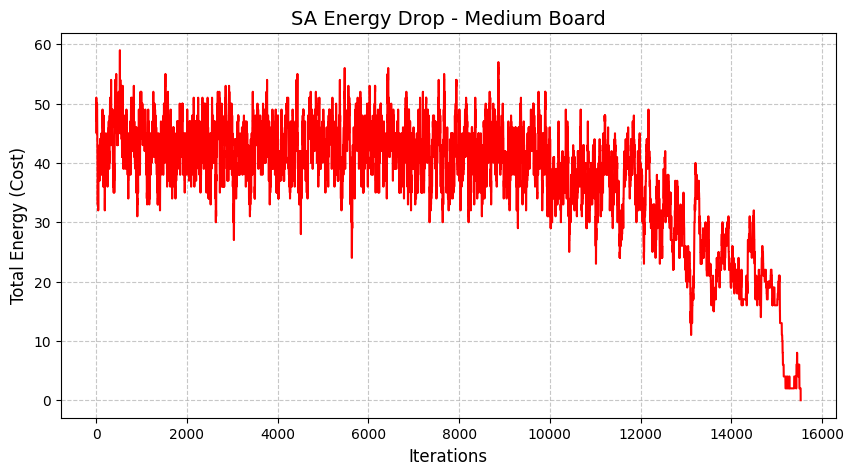

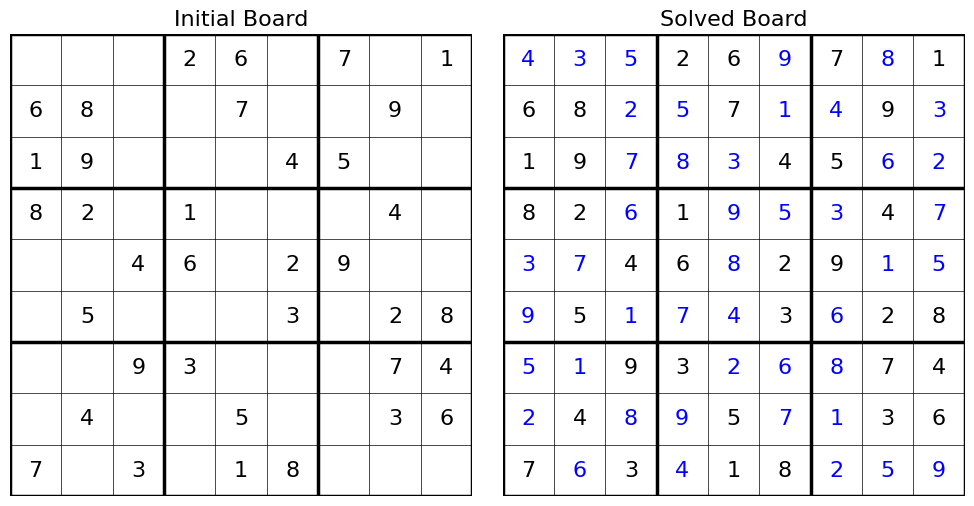



--- Solving Hard Sudoku ---
The solution of sudoku was: False
FAILED. Stuck at local minimum with energy 2 after 27625 iterations.


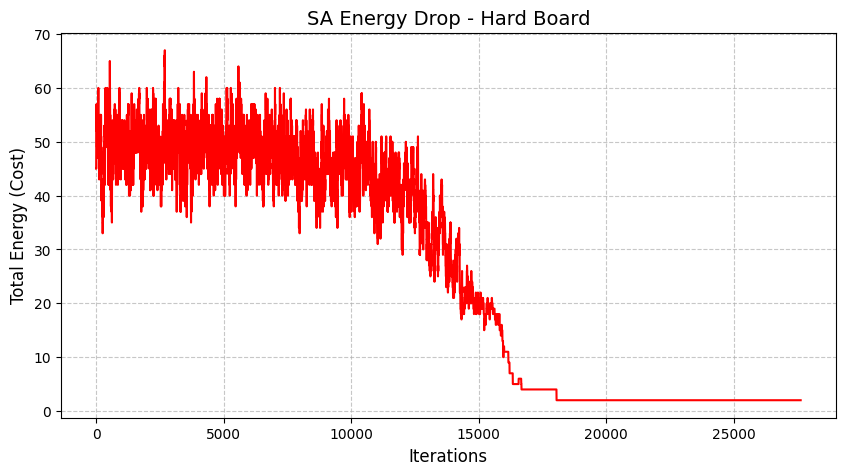

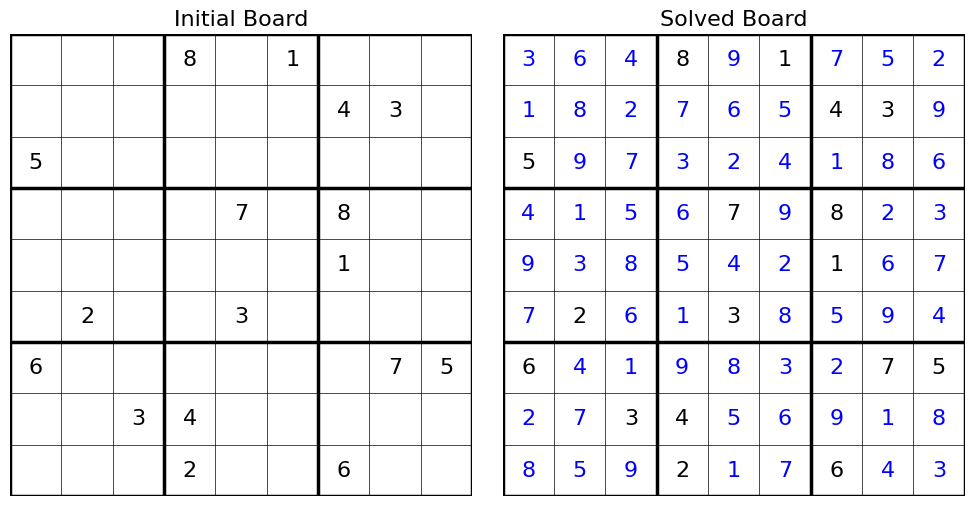

In [35]:
import matplotlib.pyplot as plt

def plot_energy_history(energies, title="Energy Drop during Simulated Annealing"):
    # Create a line plot of the energy over iterations
    plt.figure(figsize=(10, 5))
    plt.plot(energies, color='red', linewidth=1.5)
    plt.title(title, fontsize=14)
    plt.xlabel("Iterations", fontsize=12)
    plt.ylabel("Total Energy (Cost)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Display the plot
    plt.show()

if __name__ == "__main__":
    # --- SAMPLE BOARDS ---
    # 0 represents empty cells ('x')
    
    # 1. Easy Board (many given numbers)
    easy_board = [
        [5, 3, 0, 0, 7, 0, 0, 0, 0],
        [6, 0, 0, 1, 9, 5, 0, 0, 0],
        [0, 9, 8, 0, 0, 0, 0, 6, 0],
        [8, 0, 0, 0, 6, 0, 0, 0, 3],
        [4, 0, 0, 8, 0, 3, 0, 0, 1],
        [7, 0, 0, 0, 2, 0, 0, 0, 6],
        [0, 6, 0, 0, 0, 0, 2, 8, 0],
        [0, 0, 0, 4, 1, 9, 0, 0, 5],
        [0, 0, 0, 0, 8, 0, 0, 7, 9]
    ]
    
    # 2. Medium Board
    medium_board = [
        [0, 0, 0, 2, 6, 0, 7, 0, 1],
        [6, 8, 0, 0, 7, 0, 0, 9, 0],
        [1, 9, 0, 0, 0, 4, 5, 0, 0],
        [8, 2, 0, 1, 0, 0, 0, 4, 0],
        [0, 0, 4, 6, 0, 2, 9, 0, 0],
        [0, 5, 0, 0, 0, 3, 0, 2, 8],
        [0, 0, 9, 3, 0, 0, 0, 7, 4],
        [0, 4, 0, 0, 5, 0, 0, 3, 6],
        [7, 0, 3, 0, 1, 8, 0, 0, 0]
    ]
    
    # 3. Hard Board (very few givens)
    hard_board = [
        [0, 0, 0, 8, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 4, 3, 0],
        [5, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 7, 0, 8, 0, 0],
        [0, 0, 0, 0, 0, 0, 1, 0, 0],
        [0, 2, 0, 0, 3, 0, 0, 0, 0],
        [6, 0, 0, 0, 0, 0, 0, 7, 5],
        [0, 0, 3, 4, 0, 0, 0, 0, 0],
        [0, 0, 0, 2, 0, 0, 6, 0, 0]
    ]

    test_cases = [
        ("Easy", easy_board),
        ("Medium", medium_board),
        ("Hard", hard_board)
    ]
    
    # Loop through each test case
    for difficulty, board in test_cases:
        print(f"--- Solving {difficulty} Sudoku ---")
        
        # Run the Simulated Annealing solver
        # We use a slower cooling rate (0.9995) to give the algorithm 
        # a better chance at escaping local minima for harder boards.
        solved_board, iterations, energies = solve_sudoku_sa(
            board, 
            initial_temp=1000.0, 
            cooling_rate=0.9995, 
            min_temp=0.001, 
            max_iterations=300000
        )
        
        final_energy = energies[-1]
        
        print(f"The solution of sudoku was: {is_valid_sudoku(solved_board)}")
        if final_energy == 0:
            print(f"SUCCESS! Found perfect solution in {iterations} iterations.")
        else:
            print(f"FAILED. Stuck at local minimum with energy {final_energy} after {iterations} iterations.")
            
        # Plot the energy graph (Close the window to proceed to the next board)
        plot_energy_history(energies, title=f"SA Energy Drop - {difficulty} Board")
        draw_sudoku(board, solved_board)
        
        # Uncomment below to also display the visual board comparison
        # result_image = get_sudoku_image(board, solved_board)
        # result_image.show()
        print("\n")